In [37]:
!pip install h2o

In [38]:
#mount google drive
from google.colab import drive
import os
drive.mount('/content/drive')
PARQUET_PATH  = os.path.join(os.getcwd(),'drive', 'MyDrive', 'DSE_260A', 'data', 'cleaned_data')
CHALLENGE_DATA_PATH = os.path.join(os.getcwd(),'drive', 'MyDrive', 'DSE_260A', 'data', 'cleaned_data')
SUBMISSION_PATH = os.getcwd()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
import io
import re
import os
import tempfile
import warnings
from contextlib import redirect_stderr, redirect_stdout

import h2o
import numpy as np
import pandas as pd
from h2o.automl import H2OAutoML
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler


import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

#Final Data Cleaning for Task 4.5

In [40]:
df_train = pd.read_parquet(PARQUET_PATH + "/merged_data/combined.parquet")
challenge_participants = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_transcriptomics = pd.read_parquet(CHALLENGE_DATA_PATH + '/challenge_transcriptomics_cleaned.parquet')
df_challenge = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
df_challenge = df_challenge.merge(challenge_transcriptomics, on='participant_id', how='inner')

In [41]:
#drop participants who are mising more that 20% of transcriptomics columns
print('Before:', df_train.shape)
transcriptomics_cols = [col for col in df_train.columns if col.startswith("TRAN")]
df_train = df_train.dropna(subset=transcriptomics_cols, thresh=int(0.2 * len(transcriptomics_cols)))
df_train[transcriptomics_cols]
print('After:', df_train.shape)

Before: (3757, 110063)
After: (396, 110063)


In [42]:
SDY_participants = [participant for participant in df_train['participant_id'] if participant.startswith('SDY')]
df_train_SDY = df_train[df_train['participant_id'].isin(SDY_participants)]
df_train_UGA = df_train[~df_train['participant_id'].isin(SDY_participants)]
print(df_train_SDY.shape)
print(df_train_UGA.shape)

(73, 110063)
(323, 110063)


In [43]:
def dropsparsecols(df, thresh = 85):
    # Calculate the percentage of missing values for each column
    missing_percentage = df.isnull().sum() / len(df) * 100

    # Identify columns to drop (missing 85% or more values) excluding those starting with 'HAI_'
    columns_to_drop = [col for col in missing_percentage[missing_percentage >= thresh].index if not col.startswith('HAI_')]

    # Drop the identified columns from df_train
    df.drop(columns=columns_to_drop, inplace=True)

    print(f"Dropped {len(columns_to_drop)} columns with 85% or more missing values (excluding HAI_ columns).")
    print(f"New shape of df_train: {df.shape}")
    return


print('removing sparse columns from UGA')
dropsparsecols(df_train_UGA, 48)
print('removing sparse columns from SDY')
dropsparsecols(df_train_SDY, 48)

removing sparse columns from UGA
Dropped 78640 columns with 85% or more missing values (excluding HAI_ columns).
New shape of df_train: (323, 31423)
removing sparse columns from SDY
Dropped 35101 columns with 85% or more missing values (excluding HAI_ columns).
New shape of df_train: (73, 74962)


/tmp/ipykernel_14423/883859118.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=columns_to_drop, inplace=True)
/tmp/ipykernel_14423/883859118.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=columns_to_drop, inplace=True)


In [44]:
#count null vals in each col and print the result in desc order
UGA_transcriptomics_cols = [col for col in df_train_UGA.columns if col.startswith("TRAN")]
SDY_transcriptomics_cols = [col for col in df_train_SDY.columns if col.startswith("TRAN")]
print(df_train_UGA[UGA_transcriptomics_cols].isnull().sum().sort_values(ascending=False))
print(df_train_SDY[SDY_transcriptomics_cols].isnull().sum().sort_values(ascending=False))

TRAN_ENSG00000226859_d0    48
TRAN_ENSG00000122254_d0    48
TRAN_ENSG00000259385_d0    48
TRAN_ENSG00000259395_d0    48
TRAN_ENSG00000226854_d0    48
                           ..
TRAN_ENSG00000161944_d0     0
TRAN_ENSG00000161940_d0     0
TRAN_ENSG00000161929_d0     0
TRAN_ENSG00000161921_d0     0
TRAN_ENSG00000161999_d0     0
Length: 31222, dtype: int64
TRAN_ENSG00000310539_d7    1
TRAN_ENSG00000000003_d0    1
TRAN_ENSG00000000419_d0    1
TRAN_ENSG00000000457_d0    1
TRAN_ENSG00000000460_d0    1
                          ..
TRAN_ENSG00000001617_d0    1
TRAN_ENSG00000001561_d0    1
TRAN_ENSG00000001497_d0    1
TRAN_ENSG00000001461_d0    1
TRAN_ENSG00000001460_d0    1
Length: 74761, dtype: int64


In [45]:
#impute missing values in the transcriptomics cols of each data frame using Nearest neighbor imputer
imputer = KNNImputer(n_neighbors=5)
df_train_UGA[UGA_transcriptomics_cols] = imputer.fit_transform(df_train_UGA[UGA_transcriptomics_cols])
df_train_SDY[SDY_transcriptomics_cols] = imputer.fit_transform(df_train_SDY[SDY_transcriptomics_cols])



/tmp/ipykernel_14423/3225387964.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_UGA[UGA_transcriptomics_cols] = imputer.fit_transform(df_train_UGA[UGA_transcriptomics_cols])
/tmp/ipykernel_14423/3225387964.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_SDY[SDY_transcriptomics_cols] = imputer.fit_transform(df_train_SDY[SDY_transcriptomics_cols])


For this task we need to estimate the average of the following strains from the challenge set at day 28:

H1N1 A/California/7/2009            
H1N1 A/Brisbane/2/2018              
H1N1 A/Guangdong-Maonan/SWL1536/2019
H1N1 A/Victoria/2570/2019           
H1N1 A/Victoria/4897/2022           
H3N2 A/Hong Kong/4801/2014          
H3N2 A/Singapore/INFIMH-160019/2016
H3N2 A/Kansas/14/2017               
H3N2 A/Hong Kong/2671/2019          
H3N2 A/South Australia/34/2019      
H3N2 A/Tasmania/503/2020            
H3N2 A/Darwin/9/2021                
H3N2 A/Massachusetts/18/2022        
Vic B/Colorado/6/2017               
Vic B/Washington/2/2019             
Vic B/Austria/1359417/2021          
Yam B/Phuket/3073/2013

Several of these will likely be missing from the training data. Lets first explore which strains are missing

In [46]:
strains_d0 = set()
strains_d28 = set()

for col in df_train.columns:
    match_d0 = re.match(r'HAI_(.*)_d0$', col)
    if match_d0:
        strains_d0.add(match_d0.group(1))

    match_d28 = re.match(r'HAI_(.*)_d28$', col)
    if match_d28:
        strains_d28.add(match_d28.group(1))

print(strains_d0)
print(strains_d28)

challenge_strains = set([
    'H1N1 A/California/7/2009',
    'H1N1 A/Brisbane/2/2018',
    'H1N1 A/Guangdong-Maonan/SWL1536/2019',
    'H1N1 A/Victoria/2570/2019',
    'H1N1 A/Victoria/4897/2022',
    'H3N2 A/Hong Kong/4801/2014',
    'H3N2 A/Singapore/INFIMH-160019/2016',
    'H3N2 A/Kansas/14/2017',
    'H3N2 A/Hong Kong/2671/2019',
    'H3N2 A/South Australia/34/2019',
    'H3N2 A/Tasmania/503/2020',
    'H3N2 A/Darwin/9/2021',
    'H3N2 A/Massachusetts/18/2022',
    'Vic B/Colorado/6/2017',
    'Vic B/Washington/2/2019',
    'Vic B/Austria/1359417/2021',
    'Yam B/Phuket/3073/2013'
])

missing_strains = challenge_strains - strains_d28
print(missing_strains)


{'H1N1 A/Beijing/262/1995', 'H1N1 A/Victoria/4897/2022', 'H3N2 A/Tasmania/503/2020', 'H1N1 A/Texas/36/1991', 'H3N2 A/Shandong/9/1993', 'H1N1 A/Weiss/JY2/1943', 'H1N1 A/New Caledonia/20/1999', 'Anc B/Singapore/1964', 'Vic B/Malaysia/2506/2004', 'Anc B/Maryland/1959', 'H1N1 A/Chile/1/1983', 'H1N1 A/Fort Monmouth/1/1947', 'Yam B/Wisconsin/1/2010', 'H3N2 A/Perth/16/2009', 'H3N2 A/Hong Kong/2671/2019', 'H3N2 A/Switzerland/9715293/2013', 'Yam B/Massachusetts/2/2012', 'H1N1 A/Brisbane/2/2018', 'Yam B/Yamagata/16/1988', 'Vic B/Victoria/2/1987', 'H1N1 A/Brisbane/59/2007', 'H1N1 A/California/7/2009', 'Vic B/Washington/2/2019', 'H1N1 A/Guangdong-Maonan/SWL1536/2019', 'H3N2 A/Hong Kong/1/1968', 'H1N1 A/South Dakota/6/2007', 'H3N2 A/Port Chalmers/1/1973', 'Yam B/Phuket/3073/2013', 'Vic B/Austria/1359417/2021', 'H1N1 A/New Jersey/8/1976', 'Vic B/Brisbane/60/2008', 'Anc B/Lee/1940', 'H3N2 A/Singapore/INFIMH-160019/2016', 'H1N1 A/Singapore/6/1986', 'H1N1 A/Puerto Rico/8/1934', 'H1N1 A/Brazil/11/1978',

In [47]:
def calculate_breadth_features(df):
    d0_cols = [
        f"HAI_{strain}_d0"
        for strain in challenge_strains
        if f"HAI_{strain}_d0" in df.columns
    ]

    d28_cols = [
        f"HAI_{strain}_d28"
        for strain in challenge_strains
        if f"HAI_{strain}_d28" in df.columns
    ]

    print(f"Available D0 strains for current df: {len(d0_cols)}")
    print(f"Available D28 strains for current df: {len(d28_cols)}")

    # -----------------------------
    # Compute log-space geomeans
    # (values already log2 transformed)
    # -----------------------------

    df["geomean_d0"] = df[d0_cols].mean(axis=1, skipna=True)

    df["geomean_d28"] = df[d28_cols].mean(axis=1, skipna=True)

    # -----------------------------
    # Count number of strains used
    # -----------------------------

    df["n_strains_d0"] = (
        df[d0_cols]
        .notna()
        .sum(axis=1)
    )

    df["n_strains_d28"] = (
        df[d28_cols]
        .notna()
        .sum(axis=1)
    )

    # -----------------------------
    # Compute overall breadth response
    # -----------------------------

    df["breadth_delta"] = (
        df["geomean_d28"]
        - df["geomean_d0"]
    )

    return df

print("Processing df_train_UGA:")
df_train_UGA = calculate_breadth_features(df_train_UGA)
print(df_train_UGA[['geomean_d0', 'geomean_d28', 'n_strains_d0', 'n_strains_d28']].head(10))
print(f"NaNs in geomean_d0 (df_train_UGA): {df_train_UGA['geomean_d0'].isna().sum()}")
print(f"NaNs in geomean_d28 (df_train_UGA): {df_train_UGA['geomean_d28'].isna().sum()}")

print("\nProcessing df_train_SDY:")
df_train_SDY = calculate_breadth_features(df_train_SDY)
print(df_train_SDY[['geomean_d0', 'geomean_d28', 'n_strains_d0', 'n_strains_d28']].head(10))
print(f"NaNs in geomean_d0 (df_train_SDY): {df_train_SDY['geomean_d0'].isna().sum()}")
print(f"NaNs in geomean_d28 (df_train_SDY): {df_train_SDY['geomean_d28'].isna().sum()}")


Processing df_train_UGA:
Available D0 strains for current df: 16
Available D28 strains for current df: 16
      geomean_d0  geomean_d28  n_strains_d0  n_strains_d28
2369    4.412837     7.412837            11             11
2370    4.321928     5.140110            11             11
2371    4.594655     6.503746            11             11
2372    6.049201     6.140110            11             11
2373    2.776474     4.412837            11             11
2374    2.685564     4.776474            11             11
2376    3.958292     4.776474            11             11
2377    5.140110     6.049201            11             11
2378    4.867383     6.594655            11             11
2379    6.321928     8.049201            11             11
NaNs in geomean_d0 (df_train_UGA): 0
NaNs in geomean_d28 (df_train_UGA): 0

Processing df_train_SDY:
Available D0 strains for current df: 16
Available D28 strains for current df: 16
      geomean_d0  geomean_d28  n_strains_d0  n_strains_d28
3684

/tmp/ipykernel_14423/2455756104.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["geomean_d0"] = df[d0_cols].mean(axis=1, skipna=True)
/tmp/ipykernel_14423/2455756104.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["geomean_d0"] = df[d0_cols].mean(axis=1, skipna=True)
/tmp/ipykernel_14423/2455756104.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(

In [48]:
for MIN_STRAINS in range(1, 17):
    df_breadth = df_train_UGA[
      (df_train_UGA["n_strains_d0"] >= MIN_STRAINS) &
      (df_train_UGA["n_strains_d28"] >= MIN_STRAINS)
    ].copy()

    print(f'MIN_STRAIN = {MIN_STRAINS}:    ', 'Before: ', len(df_train_UGA), ' After: ', len(df_breadth), ' Dif: ', len(df_train_UGA) - len(df_breadth), ' Percent change: ', (len(df_train_UGA) - len(df_breadth)) / len(df_train_UGA))

MIN_STRAIN = 1:     Before:  323  After:  323  Dif:  0  Percent change:  0.0
MIN_STRAIN = 2:     Before:  323  After:  323  Dif:  0  Percent change:  0.0
MIN_STRAIN = 3:     Before:  323  After:  323  Dif:  0  Percent change:  0.0
MIN_STRAIN = 4:     Before:  323  After:  323  Dif:  0  Percent change:  0.0
MIN_STRAIN = 5:     Before:  323  After:  323  Dif:  0  Percent change:  0.0
MIN_STRAIN = 6:     Before:  323  After:  323  Dif:  0  Percent change:  0.0
MIN_STRAIN = 7:     Before:  323  After:  323  Dif:  0  Percent change:  0.0
MIN_STRAIN = 8:     Before:  323  After:  323  Dif:  0  Percent change:  0.0
MIN_STRAIN = 9:     Before:  323  After:  323  Dif:  0  Percent change:  0.0
MIN_STRAIN = 10:     Before:  323  After:  323  Dif:  0  Percent change:  0.0
MIN_STRAIN = 11:     Before:  323  After:  323  Dif:  0  Percent change:  0.0
MIN_STRAIN = 12:     Before:  323  After:  48  Dif:  275  Percent change:  0.8513931888544891
MIN_STRAIN = 13:     Before:  323  After:  48  Dif:  275 

In [49]:
for MIN_STRAINS in range(1, 17):
    df_breadth = df_train_SDY[
      (df_train_SDY["n_strains_d0"] >= MIN_STRAINS) &
      (df_train_SDY["n_strains_d28"] >= MIN_STRAINS)
    ].copy()

    print(f'MIN_STRAIN = {MIN_STRAINS}:    ', 'Before: ', len(df_train_SDY), ' After: ', len(df_breadth), ' Dif: ', len(df_train_SDY) - len(df_breadth), ' Percent change: ', (len(df_train_SDY) - len(df_breadth)) / len(df_train_SDY))

MIN_STRAIN = 1:     Before:  73  After:  72  Dif:  1  Percent change:  0.0136986301369863
MIN_STRAIN = 2:     Before:  73  After:  72  Dif:  1  Percent change:  0.0136986301369863
MIN_STRAIN = 3:     Before:  73  After:  66  Dif:  7  Percent change:  0.0958904109589041
MIN_STRAIN = 4:     Before:  73  After:  44  Dif:  29  Percent change:  0.3972602739726027
MIN_STRAIN = 5:     Before:  73  After:  0  Dif:  73  Percent change:  1.0
MIN_STRAIN = 6:     Before:  73  After:  0  Dif:  73  Percent change:  1.0
MIN_STRAIN = 7:     Before:  73  After:  0  Dif:  73  Percent change:  1.0
MIN_STRAIN = 8:     Before:  73  After:  0  Dif:  73  Percent change:  1.0
MIN_STRAIN = 9:     Before:  73  After:  0  Dif:  73  Percent change:  1.0
MIN_STRAIN = 10:     Before:  73  After:  0  Dif:  73  Percent change:  1.0
MIN_STRAIN = 11:     Before:  73  After:  0  Dif:  73  Percent change:  1.0
MIN_STRAIN = 12:     Before:  73  After:  0  Dif:  73  Percent change:  1.0
MIN_STRAIN = 13:     Before:  73  Af

In [50]:
part_cols_UGA = [col for col in df_train_UGA.columns if col.startswith("PART")]
part_cols_SDY = [col for col in df_train_SDY.columns if col.startswith("PART")]
part_cols_chal = [col for col in df_challenge.columns if col.startswith("PART")]

for col in part_cols_UGA:
    print(col, df_train_UGA[col].unique())

for col in part_cols_SDY:
    print(col, df_train_SDY[col].unique())

for col in part_cols_chal:
    print(col, df_challenge[col].unique())

PART_biological_sex ['Female' 'Male']
PART_race ['Unknown']
PART_geolocation ['Georgia']
PART_arm_name ['Standard Fluzone' 'High Dose Fluzone']
PART_age [31. 27. 49. 28. 64. 41. 42. 26. 33. 29. 60. 46. 25. 32. 65. 24. 48. 21.
 53. 59. 51. 58. 45. 56. 67. 69. 57. 76. 70. 38. 72. 71. 66. 73. 68. 75.
 81. 55. 35. 78. 34. 40. 44. 61. 47. 20. 63. 43. 23. 77. 80. 39. 62. 54.
 50. 74. 52. 19. 18. 30. 36. 37. 22. 85. 82.]
PART_biological_sex ['Female' 'Male']
PART_race ['Black' 'White' 'Multiracial' 'Asian']
PART_geolocation ['Virginia']
PART_arm_name ['Other']
PART_age [35.  71.  45.  28.  24.  67.  55.  23.  53.  39.  68.  44.  69.  23.5
 40.  70.5 49.  26.  33.  60.  38.5 36.  43.  24.5 34.  59.  48.  42.
 50.  66.  47.  32.  56.  22.  62.  30.  54.  37.  27.  61.  41. ]
PART_biological_sex ['Female' 'Male']
PART_race ['Unknown']
PART_geolocation ['Georgia']
PART_arm_name ['High Dose Fluzone' 'Standard Fluzone']
PART_age [72. 65. 43. 74. 70. 45. 80. 71. 66. 55. 63. 77. 76. 53. 24. 60. 42. 3

In [52]:
df_train_UGA.drop(columns = ['PART_race', 'PART_geolocation'], inplace = True) #dropping race/geolocation since they are all the same val "unknown"/'Georgia'
df_train_UGA['PART_arm_name'] = df_train_UGA['PART_arm_name'].apply(lambda x: 1.0 if x=='High Dose Fluzone' else 0.0)
df_train_UGA['PART_biological_sex'] = df_train_UGA['PART_biological_sex'].apply(lambda x: 1.0 if x=='Male' else -1.0)

agescaler = StandardScaler()
df_train_UGA['PART_age'] = agescaler.fit_transform(df_train_UGA[['PART_age']])

df_train_SDY.drop(columns = ['PART_race', 'PART_geolocation', 'PART_arm_name'], inplace = True) #dropping race/geolocation since they are all the same val "unknown"/'Georgia'
df_train_SDY['PART_biological_sex'] = df_train_SDY['PART_biological_sex'].apply(lambda x: 1.0 if x=='Male' else -1.0)

agescaler = StandardScaler()
df_train_SDY['PART_age'] = agescaler.fit_transform(df_train_SDY[['PART_age']])


df_train_UGA


/tmp/ipykernel_14423/2706840852.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_UGA.drop(columns = ['PART_race', 'PART_geolocation'], inplace = True) #dropping race/geolocation since they are all the same val "unknown"/'Georgia'
/tmp/ipykernel_14423/2706840852.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_UGA['PART_arm_name'] = df_train_UGA['PART_arm_name'].apply(lambda x: 1.0 if x=='High Dose Fluzone' else 0.0)
/tmp/ipykernel_14423/2706840852.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

,participant_id,PART_biological_sex,PART_arm_name,PART_age,HAI_Anc B/Lee/1940_d0,HAI_Anc B/Lee/1940_d28,HAI_Anc B/Lee/1940_d365,HAI_Anc B/Maryland/1959_d0,HAI_Anc B/Maryland/1959_d28,HAI_Anc B/Singapore/1964_d0,...,TRAN_ENSG00000284523_d0,TRAN_ENSG00000284526_d0,TRAN_ENSG00000284543_d0,TRAN_ENSG00000284546_d0,TRAN_ENSG00000284600_d0,geomean_d0,geomean_d28,n_strains_d0,n_strains_d28,breadth_delta
2369,2019_UGA.ID_001,-1.0,0.0,-1.123530,8.321928,11.321928,NaN,NaN,NaN,NaN,...,-0.102329,0.286336,-0.601979,-0.16742,-0.276787,4.412837,7.412837,11,11,3.000000
2370,2019_UGA.ID_005,-1.0,0.0,-1.356756,4.321928,5.321928,NaN,NaN,NaN,NaN,...,0.037661,-0.250817,0.509068,-0.16742,2.387977,4.321928,5.140110,11,11,0.818182
2371,2019_UGA.ID_008,-1.0,0.0,-0.074011,5.321928,6.321928,NaN,NaN,NaN,NaN,...,0.455394,0.214066,-0.698391,-0.16742,-0.276787,4.594655,6.503746,11,11,1.909091
2372,2019_UGA.ID_011,-1.0,0.0,-1.298450,9.321928,9.321928,NaN,NaN,NaN,NaN,...,-0.345824,-0.135486,0.163899,-0.16742,-0.276787,6.049201,6.140110,11,11,0.090909
2373,2019_UGA.ID_014,-1.0,0.0,0.800587,2.321928,4.321928,NaN,NaN,NaN,NaN,...,-0.345824,0.340708,0.123909,-0.16742,-0.276787,2.776474,4.412837,11,11,1.636364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2821,2020_UGA.ID_249,-1.0,0.0,-0.423851,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.237276,0.178180,-0.660068,-0.16742,0.615745,3.921928,4.388595,15,15,0.466667
2824,2020_UGA.ID_260,-1.0,0.0,-0.423851,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.303520,-0.166316,-1.036399,-0.16742,0.615745,4.521928,4.721928,15,15,0.200000
2826,2020_UGA.ID_264,-1.0,0.0,-1.356756,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.152121,0.416717,-0.895226,-0.16742,0.357236,3.321928,5.321928,15,15,2.000000
2923,2020_UGA.ID_395,-1.0,0.0,-0.190625,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.303520,0.285736,-0.793136,-0.16742,0.615745,3.788595,4.121928,15,15,0.333333


#Using UGA participants going forward

In [81]:
MIN_STRAIN = 11

df_train_filtered = df_train_UGA[
    (df_train_UGA["n_strains_d0"] >= MIN_STRAIN) &
    (df_train_UGA["n_strains_d28"] >= MIN_STRAIN)
].copy()

df_train_filtered.drop(columns = ['n_strains_d0', 'n_strains_d28', 'geomean_d28'], inplace = True)


In [82]:
d28_hai_cols = [c for c in df_train_filtered.columns if (c.endswith('_d28') or c.endswith('d365')) and c.startswith('HAI')]
df_train_filtered.drop(columns=d28_hai_cols, inplace=True)

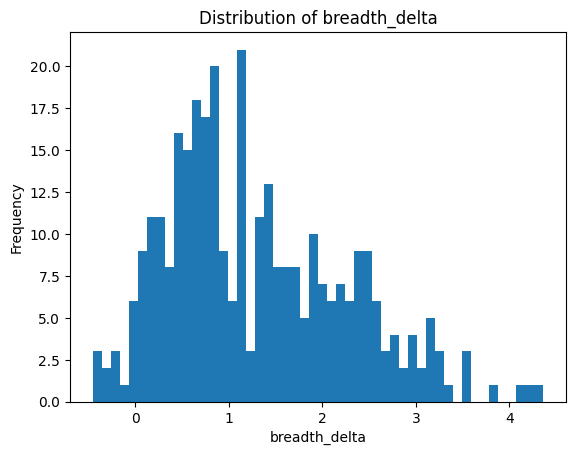

In [83]:
#plot the distribution of breadth delta
plt.hist(df_train_filtered['breadth_delta'], bins=50)
plt.xlabel('breadth_delta')
plt.ylabel('Frequency')
plt.title('Distribution of breadth_delta')
plt.show()

In [64]:
#Find the top 50 transcriptomics columns which has highest degrees of correlation with the target variable breadth_delta
#print out their correlation value as well
transcriptomics_cols = [col for col in df_train_filtered.columns if col.startswith("TRAN")]

corr_matrix = df_train_filtered[transcriptomics_cols + ['breadth_delta']].corr()
corr_with_target = corr_matrix['breadth_delta'].abs().sort_values(ascending=False)
corr_with_target.head(50)


,breadth_delta
breadth_delta,1.000000
TRAN_ENSG00000197182_d0,0.227499
TRAN_ENSG00000281990_d0,0.226031
TRAN_ENSG00000275063_d0,0.221958
TRAN_ENSG00000162881_d0,0.221333
TRAN_ENSG00000131669_d0,0.216453
TRAN_ENSG00000158825_d0,0.215281
TRAN_ENSG00000172057_d0,0.211986
TRAN_ENSG00000147234_d0,0.207741
TRAN_ENSG00000211696_d0,0.206563


In [85]:
Top_50_transcriptomics_cols = corr_with_target.head(51).index.tolist()
Top_50_transcriptomics_cols.remove('breadth_delta')
Top_50_transcriptomics_cols

['TRAN_ENSG00000197182_d0',
 'TRAN_ENSG00000281990_d0',
 'TRAN_ENSG00000275063_d0',
 'TRAN_ENSG00000162881_d0',
 'TRAN_ENSG00000131669_d0',
 'TRAN_ENSG00000158825_d0',
 'TRAN_ENSG00000172057_d0',
 'TRAN_ENSG00000147234_d0',
 'TRAN_ENSG00000211696_d0',
 'TRAN_ENSG00000268777_d0',
 'TRAN_ENSG00000182272_d0',
 'TRAN_ENSG00000185909_d0',
 'TRAN_ENSG00000274512_d0',
 'TRAN_ENSG00000130598_d0',
 'TRAN_ENSG00000149328_d0',
 'TRAN_ENSG00000236800_d0',
 'TRAN_ENSG00000246548_d0',
 'TRAN_ENSG00000183662_d0',
 'TRAN_ENSG00000142046_d0',
 'TRAN_ENSG00000183688_d0',
 'TRAN_ENSG00000177191_d0',
 'TRAN_ENSG00000105352_d0',
 'TRAN_ENSG00000125780_d0',
 'TRAN_ENSG00000135631_d0',
 'TRAN_ENSG00000211445_d0',
 'TRAN_ENSG00000248712_d0',
 'TRAN_ENSG00000266265_d0',
 'TRAN_ENSG00000114626_d0',
 'TRAN_ENSG00000235162_d0',
 'TRAN_ENSG00000271936_d0',
 'TRAN_ENSG00000135451_d0',
 'TRAN_ENSG00000240021_d0',
 'TRAN_ENSG00000229719_d0',
 'TRAN_ENSG00000167779_d0',
 'TRAN_ENSG00000152969_d0',
 'TRAN_ENSG000002671

In [86]:
#apply PCA on transcriptomics columns

df_train_filtered_PCA = df_train_filtered.copy()
from sklearn.decomposition import PCA
import pandas as pd

transcriptomics_cols = [col for col in df_train_filtered_PCA.columns if col.startswith("TRAN")]
pca = PCA(n_components=50)

# Perform PCA and create a DataFrame for the components
pca_components = pca.fit_transform(df_train_filtered_PCA[Top_50_transcriptomics_cols])
pca_col_names = [f'PCA_TRAN_{i}' for i in range(pca.n_components)]
df_pca = pd.DataFrame(pca_components, columns=pca_col_names, index=df_train_filtered_PCA.index)

# Drop original transcriptomics columns and concatenate PCA components
df_train_filtered_PCA = df_train_filtered_PCA.drop(columns=transcriptomics_cols)
df_train_filtered_PCA = pd.concat([df_train_filtered_PCA, df_pca], axis=1)

df_train_filtered_PCA

,participant_id,PART_biological_sex,PART_arm_name,PART_age,HAI_Anc B/Lee/1940_d0,HAI_Anc B/Maryland/1959_d0,HAI_Anc B/Singapore/1964_d0,HAI_H1N1 A/Beijing/262/1995_d0,HAI_H1N1 A/Brazil/11/1978_d0,HAI_H1N1 A/Brisbane/2/2018_d0,...,PCA_TRAN_40,PCA_TRAN_41,PCA_TRAN_42,PCA_TRAN_43,PCA_TRAN_44,PCA_TRAN_45,PCA_TRAN_46,PCA_TRAN_47,PCA_TRAN_48,PCA_TRAN_49
2369,2019_UGA.ID_001,-1.0,0.0,-1.123530,8.321928,NaN,NaN,NaN,NaN,5.321928,...,0.292765,0.589413,-0.188514,0.658442,-0.988666,-0.085877,0.060321,-0.314768,0.094344,0.289675
2370,2019_UGA.ID_005,-1.0,0.0,-1.356756,4.321928,NaN,NaN,NaN,NaN,3.321928,...,-0.045047,0.581780,0.016716,0.552701,0.766127,0.246091,1.086241,-0.194267,0.011651,-0.502279
2371,2019_UGA.ID_008,-1.0,0.0,-0.074011,5.321928,NaN,NaN,NaN,NaN,5.321928,...,0.759682,-0.433314,0.175863,0.174672,-0.287041,-0.244492,0.645508,0.469867,0.342531,-0.280827
2372,2019_UGA.ID_011,-1.0,0.0,-1.298450,9.321928,NaN,NaN,NaN,NaN,7.321928,...,-0.141989,0.478511,0.358913,0.061200,-0.370336,-0.072312,-0.815605,0.345527,0.078531,0.134183
2373,2019_UGA.ID_014,-1.0,0.0,0.800587,2.321928,NaN,NaN,NaN,NaN,2.321928,...,-0.361977,0.270269,-0.060243,0.684725,-0.160725,-0.456631,0.224270,0.341958,-0.332981,0.140915
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2821,2020_UGA.ID_249,-1.0,0.0,-0.423851,NaN,NaN,NaN,NaN,NaN,3.321928,...,-0.831129,-0.629817,-0.342219,0.129539,-0.142803,-0.113680,0.204322,-0.904032,0.034902,0.441519
2824,2020_UGA.ID_260,-1.0,0.0,-0.423851,NaN,NaN,NaN,NaN,NaN,2.321928,...,-0.613607,-0.428850,-0.221236,0.172918,-0.547097,-0.551698,0.134345,-0.430622,0.442562,-0.100528
2826,2020_UGA.ID_264,-1.0,0.0,-1.356756,NaN,NaN,NaN,NaN,NaN,2.321928,...,-0.524098,1.130432,-1.054766,-0.319095,-0.312064,1.211180,-0.691568,0.619680,-0.210690,-0.331781
2923,2020_UGA.ID_395,-1.0,0.0,-0.190625,NaN,NaN,NaN,NaN,NaN,5.321928,...,-0.505444,1.353545,0.496775,0.050221,-0.522360,0.187553,0.807013,-0.970468,0.199681,0.444963


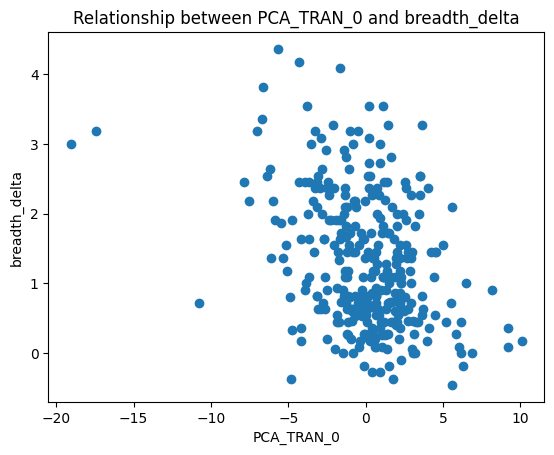

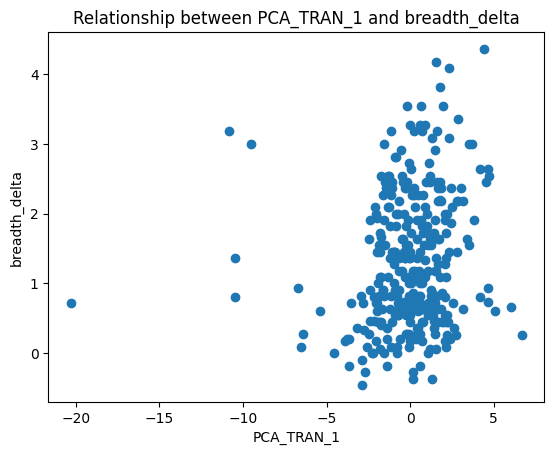

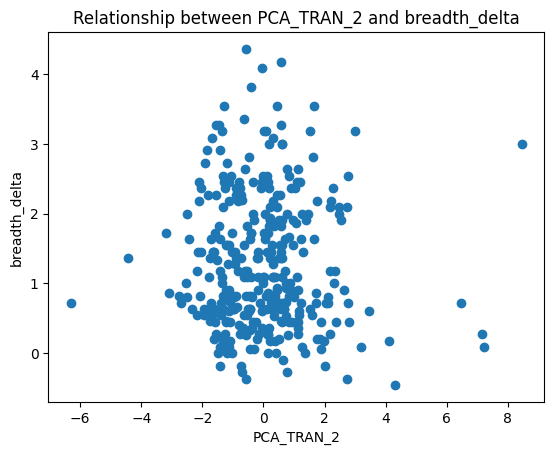

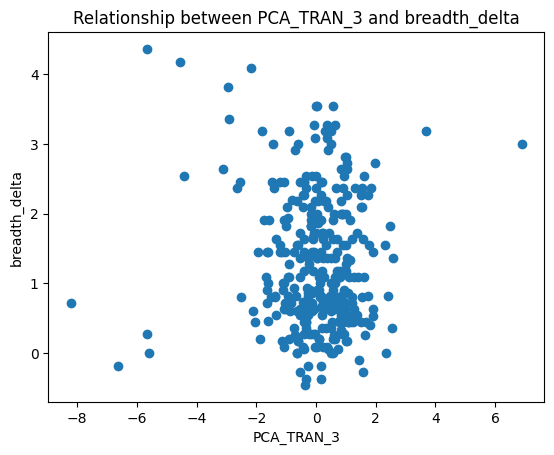

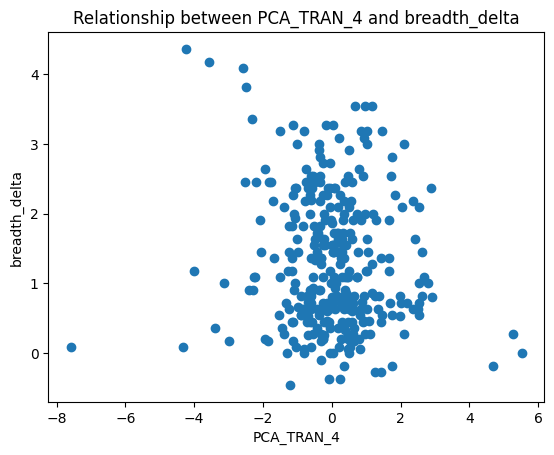

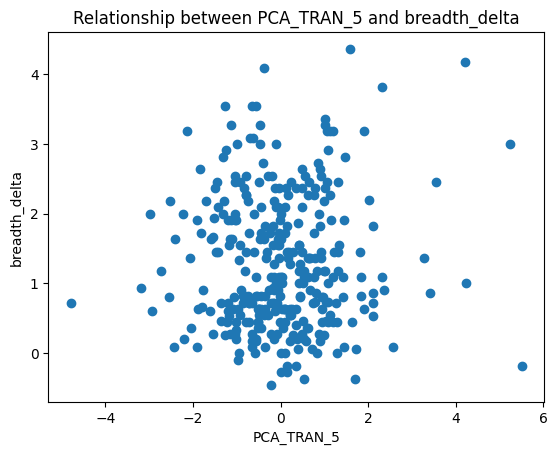

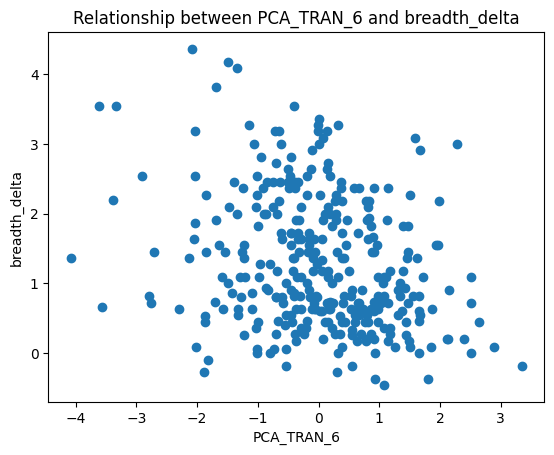

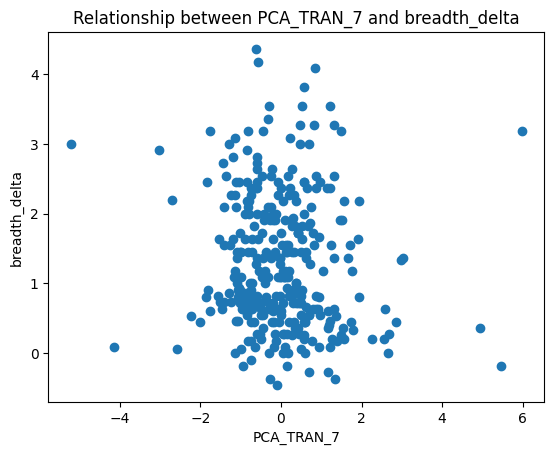

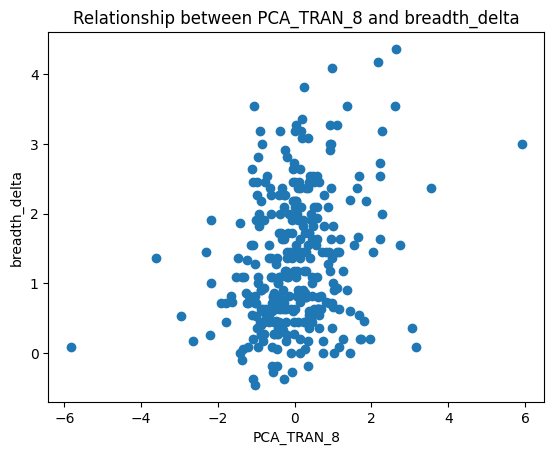

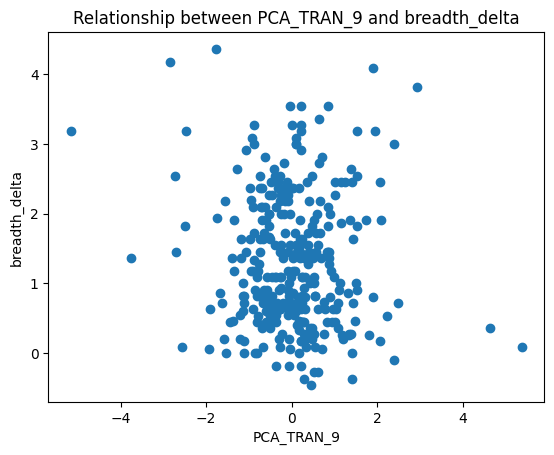

In [87]:
#for the first 10 PCA components of transcriptomics data plot its relationship with breadth_delta
for i in range(10):
    plt.scatter(df_train_filtered_PCA[pca_col_names[i]], df_train_filtered_PCA['breadth_delta'])
    plt.xlabel(pca_col_names[i])
    plt.ylabel('breadth_delta')
    plt.title(f'Relationship between {pca_col_names[i]} and breadth_delta')
    plt.show()

In [88]:
#print variance captured by each principle component
print(pca.explained_variance_ratio_)


[0.21642303 0.12780862 0.05213609 0.03984682 0.03760184 0.03169171
 0.02787135 0.0272003  0.02437624 0.02277324 0.02139894 0.02043622
 0.01988619 0.01917633 0.01738512 0.0169468  0.01647945 0.0158593
 0.01550158 0.01491731 0.01436261 0.01307472 0.01262395 0.01216842
 0.01184279 0.01126733 0.01095007 0.01008389 0.00990302 0.00894885
 0.00853248 0.00805265 0.00794146 0.00729762 0.00687307 0.00660168
 0.00640384 0.00554315 0.00545034 0.00495819 0.00432173 0.00417861
 0.00414784 0.00381651 0.00335676 0.00291503 0.00257071 0.00236561
 0.00201363 0.00171697]


In [89]:
#Pick just the top 5 PCs
df_train_filtered = df_train_filtered_PCA.drop(columns=pca_col_names[5:])
df_train_filtered

,participant_id,PART_biological_sex,PART_arm_name,PART_age,HAI_Anc B/Lee/1940_d0,HAI_Anc B/Maryland/1959_d0,HAI_Anc B/Singapore/1964_d0,HAI_H1N1 A/Beijing/262/1995_d0,HAI_H1N1 A/Brazil/11/1978_d0,HAI_H1N1 A/Brisbane/2/2018_d0,...,HAI_Yam B/Texas/6/2011_d0,HAI_Yam B/Wisconsin/1/2010_d0,HAI_Yam B/Yamagata/16/1988_d0,geomean_d0,breadth_delta,PCA_TRAN_0,PCA_TRAN_1,PCA_TRAN_2,PCA_TRAN_3,PCA_TRAN_4
2369,2019_UGA.ID_001,-1.0,0.0,-1.123530,8.321928,NaN,NaN,NaN,NaN,5.321928,...,NaN,NaN,NaN,4.412837,3.000000,-3.534866,3.697222,0.590363,0.502578,-0.999072
2370,2019_UGA.ID_005,-1.0,0.0,-1.356756,4.321928,NaN,NaN,NaN,NaN,3.321928,...,NaN,NaN,NaN,4.321928,0.818182,-3.139697,-1.555710,-0.412516,1.733466,0.926223
2371,2019_UGA.ID_008,-1.0,0.0,-0.074011,5.321928,NaN,NaN,NaN,NaN,5.321928,...,NaN,NaN,NaN,4.594655,1.909091,-4.764995,0.647448,1.406282,-1.728342,-2.081992
2372,2019_UGA.ID_011,-1.0,0.0,-1.298450,9.321928,NaN,NaN,NaN,NaN,7.321928,...,NaN,NaN,NaN,6.049201,0.090909,0.597029,2.167994,-1.407632,-1.066364,0.196406
2373,2019_UGA.ID_014,-1.0,0.0,0.800587,2.321928,NaN,NaN,NaN,NaN,2.321928,...,NaN,NaN,NaN,2.776474,1.636364,-2.691031,-0.504457,-0.447595,0.567939,-1.010943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2821,2020_UGA.ID_249,-1.0,0.0,-0.423851,NaN,NaN,NaN,NaN,NaN,3.321928,...,NaN,NaN,NaN,3.921928,0.466667,-0.874486,-2.395419,-1.238020,1.121225,0.938299
2824,2020_UGA.ID_260,-1.0,0.0,-0.423851,NaN,NaN,NaN,NaN,NaN,2.321928,...,NaN,NaN,NaN,4.521928,0.200000,-2.489836,-3.751352,-0.199671,-0.920023,0.273670
2826,2020_UGA.ID_264,-1.0,0.0,-1.356756,NaN,NaN,NaN,NaN,NaN,2.321928,...,NaN,NaN,NaN,3.321928,2.000000,-3.688851,-0.370968,-0.350495,0.831592,-0.226150
2923,2020_UGA.ID_395,-1.0,0.0,-0.190625,NaN,NaN,NaN,NaN,NaN,5.321928,...,NaN,NaN,NaN,3.788595,0.333333,-4.734132,-2.784547,-0.428451,0.840175,0.394401


#Data Preprocessing for Challenge Set

In [90]:
d0_cols_challenge = [
    f"HAI_{strain}_d0"
    for strain in challenge_strains
    if f"HAI_{strain}_d0" in df_challenge.columns
]

print("Available D0 strains in df_challenge:", len(d0_cols_challenge))

# Compute log-space geomeans for df_challenge
df_challenge["geomean_d0"] = df_challenge[d0_cols_challenge].mean(axis=1, skipna=True)

print(df_challenge[['geomean_d0']].head())


Available D0 strains in df_challenge: 17
   geomean_d0
0    3.263105
1    4.674869
2    6.204281
3    4.027810
4    4.145458


In [91]:
#Apply PCA to the challenge set for the same 50
df_challenge_PCA = df_challenge.copy()
transcriptomics_cols = [col for col in df_challenge_PCA.columns if col.startswith("TRAN")]


# Perform PCA and create a DataFrame for the components
pca_components = pca.transform(df_challenge_PCA[Top_50_transcriptomics_cols])
pca_col_names = [f'PCA_TRAN_{i}' for i in range(pca.n_components)]
df_pca = pd.DataFrame(pca_components, columns=pca_col_names, index=df_challenge_PCA.index)

df_challenge = df_challenge.drop(columns=transcriptomics_cols)
df_challenge = pd.concat([df_challenge, df_pca], axis=1)

df_challenge

,participant_id,HAI_H1N1 A/Brisbane/2/2018_d0,HAI_H1N1 A/California/7/2009_d0,HAI_H1N1 A/Guangdong-Maonan/SWL1536/2019_d0,HAI_H1N1 A/Victoria/2570/2019_d0,HAI_H1N1 A/Victoria/4897/2022_d0,HAI_H3N2 A/Darwin/9/2021_d0,HAI_H3N2 A/Hong Kong/2671/2019_d0,HAI_H3N2 A/Hong Kong/4801/2014_d0,HAI_H3N2 A/Kansas/14/2017_d0,...,PCA_TRAN_40,PCA_TRAN_41,PCA_TRAN_42,PCA_TRAN_43,PCA_TRAN_44,PCA_TRAN_45,PCA_TRAN_46,PCA_TRAN_47,PCA_TRAN_48,PCA_TRAN_49
0,2024_UGA.ID_077,2.321928,4.321928,2.321928,2.321928,2.321928,2.321928,4.321928,3.321928,3.321928,...,-10.580258,-31.686763,28.521488,17.616973,-20.074573,6.129525,2.820019,56.949742,-42.472364,3.221041
1,2024_UGA.ID_086,8.321928,9.321928,9.321928,6.321928,4.321928,2.321928,2.321928,2.321928,2.321928,...,-17.364594,-56.133775,30.275414,45.843509,-38.221026,17.642876,-5.655404,79.883314,-64.965652,2.891227
2,2024_UGA.ID_128,6.321928,7.321928,6.321928,6.321928,5.321928,6.321928,7.321928,7.321928,7.321928,...,-10.107011,2.874238,11.167719,59.539209,9.551906,-1.437830,11.916274,47.562712,-42.508553,-13.696424
3,2024_UGA.ID_170,3.321928,3.321928,3.321928,5.321928,2.321928,3.321928,5.321928,3.321928,4.321928,...,3.529496,-6.407647,31.134849,18.100336,12.466938,-11.886543,7.814154,35.729236,-49.275408,-8.092904
4,2024_UGA.ID_179,5.321928,3.321928,2.321928,6.321928,2.321928,4.321928,3.321928,2.321928,6.321928,...,-19.104595,-54.991904,20.558399,53.488612,-28.162012,5.561234,4.648727,72.168285,-77.601364,-9.265068
5,2024_UGA.ID_215,2.321928,3.321928,2.321928,2.321928,2.321928,5.321928,7.321928,6.321928,6.321928,...,-17.883587,-56.371262,19.945153,38.853814,-29.659908,10.315040,1.185083,100.729650,-74.075663,-2.893434
6,2024_UGA.ID_219,6.321928,6.321928,6.321928,5.321928,2.321928,3.321928,4.321928,2.321928,3.321928,...,-4.619268,-70.037503,15.065198,73.137897,-6.158179,8.155367,-1.117632,89.310008,-110.104440,-33.908865
7,2024_UGA.ID_275,3.321928,2.321928,5.321928,3.321928,3.321928,2.321928,3.321928,2.321928,3.321928,...,-4.396472,-13.877503,14.415405,11.102334,-12.611269,2.816074,-15.598887,43.676149,-50.402225,8.388360
8,2024_UGA.ID_295,6.321928,2.321928,5.321928,6.321928,4.321928,2.321928,2.321928,2.321928,4.321928,...,-14.871972,-33.880128,28.824931,13.003800,-12.270621,10.613237,-5.339387,54.626477,-32.867814,-0.999906
9,2024_UGA.ID_296,5.321928,4.321928,4.321928,3.321928,2.321928,2.321928,2.321928,2.321928,2.321928,...,-14.658729,-69.218321,22.895582,47.780999,-7.449019,5.045220,-14.837917,72.454595,-75.033496,-18.492774


In [92]:
df_challenge.drop(columns=pca_col_names[5:], inplace=True)
df_challenge

,participant_id,HAI_H1N1 A/Brisbane/2/2018_d0,HAI_H1N1 A/California/7/2009_d0,HAI_H1N1 A/Guangdong-Maonan/SWL1536/2019_d0,HAI_H1N1 A/Victoria/2570/2019_d0,HAI_H1N1 A/Victoria/4897/2022_d0,HAI_H3N2 A/Darwin/9/2021_d0,HAI_H3N2 A/Hong Kong/2671/2019_d0,HAI_H3N2 A/Hong Kong/4801/2014_d0,HAI_H3N2 A/Kansas/14/2017_d0,...,PART_race,PART_geolocation,PART_arm_name,PART_age,geomean_d0,PCA_TRAN_0,PCA_TRAN_1,PCA_TRAN_2,PCA_TRAN_3,PCA_TRAN_4
0,2024_UGA.ID_077,2.321928,4.321928,2.321928,2.321928,2.321928,2.321928,4.321928,3.321928,3.321928,...,Unknown,Georgia,High Dose Fluzone,72.0,3.263105,61.896913,76.872660,-25.700667,32.070530,-20.782397
1,2024_UGA.ID_086,8.321928,9.321928,9.321928,6.321928,4.321928,2.321928,2.321928,2.321928,2.321928,...,Unknown,Georgia,High Dose Fluzone,65.0,4.674869,106.801401,68.668600,-60.430628,13.874134,-29.156938
2,2024_UGA.ID_128,6.321928,7.321928,6.321928,6.321928,5.321928,6.321928,7.321928,7.321928,7.321928,...,Unknown,Georgia,Standard Fluzone,43.0,6.204281,48.200995,75.666733,-24.364144,-31.947728,-71.268935
3,2024_UGA.ID_170,3.321928,3.321928,3.321928,5.321928,2.321928,3.321928,5.321928,3.321928,4.321928,...,Unknown,Georgia,High Dose Fluzone,74.0,4.027810,43.243128,93.576045,-21.533282,42.282975,-15.082316
4,2024_UGA.ID_179,5.321928,3.321928,2.321928,6.321928,2.321928,4.321928,3.321928,2.321928,6.321928,...,Unknown,Georgia,High Dose Fluzone,70.0,4.145458,103.871994,70.873213,-52.662405,5.599555,-43.326829
5,2024_UGA.ID_215,2.321928,3.321928,2.321928,2.321928,2.321928,5.321928,7.321928,6.321928,6.321928,...,Unknown,Georgia,Standard Fluzone,43.0,4.851340,110.192731,85.365038,-52.740908,32.441527,-28.029931
6,2024_UGA.ID_219,6.321928,6.321928,6.321928,5.321928,2.321928,3.321928,4.321928,2.321928,3.321928,...,Unknown,Georgia,Standard Fluzone,45.0,4.792516,126.588253,80.148394,-86.153281,24.783006,-32.735347
7,2024_UGA.ID_275,3.321928,2.321928,5.321928,3.321928,3.321928,2.321928,3.321928,2.321928,3.321928,...,Unknown,Georgia,High Dose Fluzone,80.0,3.616046,33.047137,124.412266,-20.464436,33.166687,-26.436666
8,2024_UGA.ID_295,6.321928,2.321928,5.321928,6.321928,4.321928,2.321928,2.321928,2.321928,4.321928,...,Unknown,Georgia,High Dose Fluzone,71.0,4.204281,71.920606,92.389206,-19.910185,40.089341,-26.100895
9,2024_UGA.ID_296,5.321928,4.321928,4.321928,3.321928,2.321928,2.321928,2.321928,2.321928,2.321928,...,Unknown,Georgia,High Dose Fluzone,72.0,3.263105,134.127282,74.734570,-68.278443,4.704860,-46.414984


In [95]:
train_cols = set(list(df_train_filtered.columns))
challenge_cols = set(list(df_challenge.columns))
common_cols = train_cols.intersection(challenge_cols)

print(common_cols)
print(train_cols - common_cols)
print(challenge_cols - common_cols)
print(train_cols-common_cols-set(['breadth_delta']))

{'HAI_Vic B/Washington/2/2019_d0', 'HAI_H3N2 A/Kansas/14/2017_d0', 'PCA_TRAN_3', 'HAI_H3N2 A/Darwin/9/2021_d0', 'HAI_H1N1 A/Brisbane/2/2018_d0', 'PCA_TRAN_2', 'HAI_Vic B/Austria/1359417/2021_d0', 'HAI_H1N1 A/Victoria/4897/2022_d0', 'HAI_H1N1 A/Guangdong-Maonan/SWL1536/2019_d0', 'PCA_TRAN_4', 'HAI_H3N2 A/South Australia/34/2019_d0', 'HAI_H3N2 A/Hong Kong/4801/2014_d0', 'PART_biological_sex', 'geomean_d0', 'HAI_H1N1 A/Victoria/2570/2019_d0', 'HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0', 'PART_arm_name', 'HAI_H3N2 A/Hong Kong/2671/2019_d0', 'HAI_H3N2 A/Tasmania/503/2020_d0', 'participant_id', 'HAI_Yam B/Phuket/3073/2013_d0', 'HAI_Vic B/Colorado/6/2017_d0', 'HAI_H1N1 A/California/7/2009_d0', 'PCA_TRAN_1', 'PCA_TRAN_0', 'PART_age'}
{'HAI_H3N2 A/Nanchang/933/1995_d0', 'HAI_Vic B/Brisbane/60/2008_d0', 'HAI_H3N2 A/Mississippi/1/1985_d0', 'HAI_Yam B/Yamagata/16/1988_d0', 'HAI_H3N2 A/Texas/1/1977_d0', 'HAI_H1N1 A/New Jersey/8/1976_d0', 'HAI_H3N2 A/Victoria/361/2011_d0', 'HAI_Yam B/Massachusetts/

In [96]:
df_challenge = df_challenge[list(common_cols)]
df_challenge['PART_arm_name'] = df_challenge['PART_arm_name'].apply(lambda x: 1.0 if x=='High Dose Fluzone' else 0.0)
df_challenge['PART_biological_sex'] = df_challenge['PART_biological_sex'].apply(lambda x: 1.0 if x=='Male' else -1.0)
df_challenge['PART_age'] = agescaler.transform(df_challenge[['PART_age']])
df_challenge

/tmp/ipykernel_14423/2640273677.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_challenge['PART_arm_name'] = df_challenge['PART_arm_name'].apply(lambda x: 1.0 if x=='High Dose Fluzone' else 0.0)
/tmp/ipykernel_14423/2640273677.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_challenge['PART_biological_sex'] = df_challenge['PART_biological_sex'].apply(lambda x: 1.0 if x=='Male' else -1.0)
/tmp/ipykernel_14423/2640273677.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sl

,HAI_Vic B/Washington/2/2019_d0,HAI_H3N2 A/Kansas/14/2017_d0,PCA_TRAN_3,HAI_H3N2 A/Darwin/9/2021_d0,HAI_H1N1 A/Brisbane/2/2018_d0,PCA_TRAN_2,HAI_Vic B/Austria/1359417/2021_d0,HAI_H1N1 A/Victoria/4897/2022_d0,HAI_H1N1 A/Guangdong-Maonan/SWL1536/2019_d0,PCA_TRAN_4,...,PART_arm_name,HAI_H3N2 A/Hong Kong/2671/2019_d0,HAI_H3N2 A/Tasmania/503/2020_d0,participant_id,HAI_Yam B/Phuket/3073/2013_d0,HAI_Vic B/Colorado/6/2017_d0,HAI_H1N1 A/California/7/2009_d0,PCA_TRAN_1,PCA_TRAN_0,PART_age
0,2.321928,3.321928,32.070530,2.321928,2.321928,-25.700667,4.321928,2.321928,2.321928,-20.782397,...,1.0,4.321928,3.321928,2024_UGA.ID_077,4.321928,2.321928,4.321928,76.872660,61.896913,1.741237
1,4.321928,2.321928,13.874134,2.321928,8.321928,-60.430628,5.321928,4.321928,9.321928,-29.156938,...,1.0,2.321928,3.321928,2024_UGA.ID_086,5.321928,5.321928,9.321928,68.668600,106.801401,1.271948
2,3.321928,7.321928,-31.947728,6.321928,6.321928,-24.364144,3.321928,5.321928,6.321928,-71.268935,...,0.0,7.321928,7.321928,2024_UGA.ID_128,5.321928,3.321928,7.321928,75.666733,48.200995,-0.202961
3,2.321928,4.321928,42.282975,3.321928,3.321928,-21.533282,3.321928,2.321928,3.321928,-15.082316,...,1.0,5.321928,6.321928,2024_UGA.ID_170,3.321928,2.321928,3.321928,93.576045,43.243128,1.875320
4,4.321928,6.321928,5.599555,4.321928,5.321928,-52.662405,5.321928,2.321928,2.321928,-43.326829,...,1.0,3.321928,3.321928,2024_UGA.ID_179,7.321928,4.321928,3.321928,70.873213,103.871994,1.607154
5,4.321928,6.321928,32.441527,5.321928,2.321928,-52.740908,4.321928,2.321928,2.321928,-28.029931,...,0.0,7.321928,8.321928,2024_UGA.ID_215,3.321928,5.321928,3.321928,85.365038,110.192731,-0.202961
6,7.321928,3.321928,24.783006,3.321928,6.321928,-86.153281,5.321928,2.321928,6.321928,-32.735347,...,0.0,4.321928,4.321928,2024_UGA.ID_219,6.321928,7.321928,6.321928,80.148394,126.588253,-0.068878
7,4.321928,3.321928,33.166687,2.321928,3.321928,-20.464436,4.321928,3.321928,5.321928,-26.436666,...,1.0,3.321928,4.321928,2024_UGA.ID_275,7.321928,4.321928,2.321928,124.412266,33.047137,2.277567
8,4.321928,4.321928,40.089341,2.321928,6.321928,-19.910185,9.321928,4.321928,5.321928,-26.100895,...,1.0,2.321928,2.321928,2024_UGA.ID_295,4.321928,5.321928,2.321928,92.389206,71.920606,1.674196
9,4.321928,2.321928,4.704860,2.321928,5.321928,-68.278443,4.321928,2.321928,4.321928,-46.414984,...,1.0,2.321928,2.321928,2024_UGA.ID_296,3.321928,3.321928,4.321928,74.734570,134.127282,1.741237


In [97]:
df_train_filtered = df_train_filtered[list(common_cols) + ['breadth_delta']]

In [98]:
df_train_filtered.to_parquet(os.path.join(os.getcwd(), '4.5_train_temp.parquet'), index=False)

# Task 4.5 — Geo Mean HAI Across All Variants (D28)

**4.5 Predict antibody breadth - all variants (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Geo mean / Metric: Spearman correlation
* Full description: Geomean HAI across all measured variants at Day 28

---

**Target:** arithmetic mean of log2 HAI at D28 across all measured strains = log2(geometric mean) on the raw titer scale. Any participant with at least one D28 HAI measurement is included. `np.exp2` is applied to predictions before saving.

**Features:** all columns available at D0 + D7 (demographics, baseline HAI, transcriptomics). All D28 and D365 columns excluded to prevent leakage.

**CV:** 5-fold; Spearman correlation on holdout predictions.

In [99]:
TARGET_COL = 'breadth_delta'  # task 4.5

In [100]:
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.18" 2026-01-20; OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1); OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp8ori9vvu
  JVM stdout: /tmp/tmp8ori9vvu/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmp8ori9vvu/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,2 months and 5 days
H2O_cluster_name:,H2O_from_python_unknownUser_5szspi
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,12.75 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


In [101]:
data = h2o.import_file(os.path.join(os.getcwd(), '4.5_train_temp.parquet'))

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [102]:
x = [c for c in data.columns if c != 'participant_id']
y = TARGET_COL
x = [c for c in x if c != y]

In [103]:
train, test = data.split_frame(ratios=[.8], seed=1234)

In [104]:
aml = H2OAutoML(max_models=50, seed=1, nfolds=5,
                keep_cross_validation_predictions=True,
                max_runtime_secs=5400)

aml.train(x=x, y=y, training_frame=train)

AutoML progress: |
01:00:49.706: _train param, Dropping bad and constant columns: [HAI_H1N1 A/Victoria/4897/2022_d0]


01:00:51.332: _train param, Dropping bad and constant columns: [HAI_H1N1 A/Victoria/4897/2022_d0]


01:00:51.698: _train param, Dropping bad and constant columns: [HAI_H1N1 A/Victoria/4897/2022_d0]

█
01:00:52.397: _train param, Dropping bad and constant columns: [HAI_H1N1 A/Victoria/4897/2022_d0]

███
01:00:54.516: _train param, Dropping bad and constant columns: [HAI_H1N1 A/Victoria/4897/2022_d0]

█
01:00:55.900: _train param, Dropping bad and constant columns: [HAI_H1N1 A/Victoria/4897/2022_d0]
01:00:56.177: _train param, Dropping bad and constant columns: [HAI_H1N1 A/Victoria/4897/2022_d0]

█
01:00:56.501: _train param, Dropping bad and constant columns: [HAI_H1N1 A/Victoria/4897/2022_d0]
01:00:56.816: _train param, Dropping bad and constant columns: [HAI_H1N1 A/Victoria/4897/2022_d0]

████
01:00:59.128: _train param, Dropping bad and constant columns: [HAI_H1N1 A/

key,value
Stacking strategy,cross_validation
Number of base models (used / total),13/50
# GBM base models (used / total),3/15
# XGBoost base models (used / total),2/18
# GLM base models (used / total),0/1
# DRF base models (used / total),0/2
# DeepLearning base models (used / total),8/14
Metalearner algorithm,GLM
Metalearner fold assignment scheme,Random
Metalearner nfolds,5


In [105]:
lb = aml.leaderboard
print(lb.head(rows=lb.nrows))

model_id                                                    rmse       mse       mae       rmsle    mean_residual_deviance
StackedEnsemble_AllModels_1_AutoML_1_20260518_10049     0.807543  0.652126  0.637318    0.367825                  0.652126
StackedEnsemble_BestOfFamily_1_AutoML_1_20260518_10049  0.808821  0.654192  0.629763    0.367836                  0.654192
GBM_grid_1_AutoML_1_20260518_10049_model_9              0.812042  0.659412  0.648863    0.37651                   0.659412
GBM_grid_1_AutoML_1_20260518_10049_model_8              0.820659  0.673481  0.656226    0.377578                  0.673481
GBM_grid_1_AutoML_1_20260518_10049_model_7              0.824234  0.679362  0.651894    0.378741                  0.679362
GBM_grid_1_AutoML_1_20260518_10049_model_3              0.825186  0.680933  0.651465    0.378964                  0.680933
GBM_grid_1_AutoML_1_20260518_10049_model_10             0.831437  0.691287  0.661186    0.384583                  0.691287
GBM_grid_1_AutoM

In [106]:
print(aml.leader)

Model Details
H2OStackedEnsembleEstimator : Stacked Ensemble
Model Key: StackedEnsemble_AllModels_1_AutoML_1_20260518_10049


Model Summary for Stacked Ensemble: 
key                                        value
-----------------------------------------  ----------------
Stacking strategy                          cross_validation
Number of base models (used / total)       13/50
# GBM base models (used / total)           3/15
# XGBoost base models (used / total)       2/18
# GLM base models (used / total)           0/1
# DRF base models (used / total)           0/2
# DeepLearning base models (used / total)  8/14
Metalearner algorithm                      GLM
Metalearner fold assignment scheme         Random
Metalearner nfolds                         5
Metalearner fold_column
Custom metalearner hyperparameters         None

ModelMetricsRegressionGLM: stackedensemble
** Reported on train data. **

MSE: 0.02239881610717357
RMSE: 0.14966234031035855
MAE: 0.12136202263880382
RMSLE: 0.0837483

In [107]:
predictions = aml.leader.predict(test)

results = test[y].cbind(predictions["predict"])
results.columns = ["actual", "predicted"]

# Filter out rows where actual is NaN
results_clean = results[results["actual"].isna() == 0]

print(results_clean.head(20))

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
   actual    predicted
0.0909091     0.84746
1.72727       0.422843
1.90909       1.50707
0.0909091     0.699637
2.90909       1.75492
2.27273       0.77066
2.18182       1.51889
2.45455       2.61657
2.36364       1.83429
1.09091       1.64844
1.36364       0.942256
1.45455       0.450811
2.45455       1.62246
1.45455       1.44936
0.727273      1.13756
2.45455       1.87644
0.272727      0.943351
2.90909       1.49982
0.727273      0.71212
1             1.29753
[20 rows x 2 columns]



/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Spearman (results_clean): 0.653  (p-value: 0.0000)


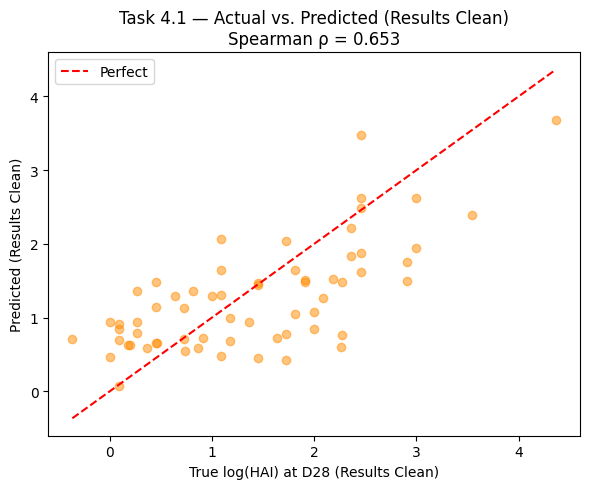

In [108]:
actual_values = results_clean['actual'].as_data_frame().to_numpy()
predicted_values = results_clean['predicted'].as_data_frame().to_numpy()

rho_results, pval_results = spearmanr(actual_values, predicted_values)
print(f'Spearman (results_clean): {rho_results:.3f}  (p-value: {pval_results:.4f})')

plt.figure(figsize=(6, 5))
plt.scatter(actual_values, predicted_values, alpha=0.5, color='darkorange')
plt.plot([actual_values.min(), actual_values.max()], [actual_values.min(), actual_values.max()], 'r--', label='Perfect')
plt.xlabel('True log(HAI) at D28 (Results Clean)')
plt.ylabel('Predicted (Results Clean)')
plt.title(f'Task 4.1 — Actual vs. Predicted (Results Clean)\nSpearman ρ = {rho_results:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

First 5 actual HAI D28 values (Original Scale):
 [[ 70.5273004 ]
 [264.88104956]
 [ 66.22026239]
 [ 42.60164358]
 [ 62.17625127]]

First 5 predicted HAI D28 values (Original Scale):
 [[119.15215589]
 [107.24536535]
 [ 50.11523426]
 [ 64.96384359]
 [ 27.93723892]]


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


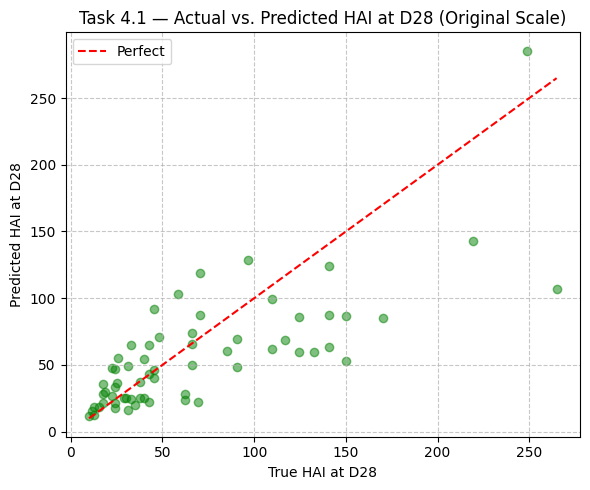

In [109]:
# Flag to toggle between log scale (1) and original scale (0) results
convert_to_original_scale = 0 # Set to 0 for original scale, 1 for log2 scale

# Get the Day 0 HAI values for the test set corresponding to the cleaned results
test_d0_hai_column_name = 'geomean_d0'

# Filter the original 'test' H2OFrame using the same condition that created results_clean.
# results_clean was created from `results[results["actual"].isna() == 0]`,
# where `results["actual"]` corresponds to `test[y]` for the relevant rows.
filtered_test_for_d0_h2o = test[test[y].isna() == 0]

# Now, extract the d0 HAI column from this filtered H2OFrame
test_d0_hai_h2o_filtered = filtered_test_for_d0_h2o[test_d0_hai_column_name]

# Convert it to a numpy array. The 'actual_values' and 'predicted_values' are already numpy arrays.
test_d0_hai = test_d0_hai_h2o_filtered.as_data_frame().values.reshape(-1, 1)

# Calculate actual HAI d28 values (log2 scale)
actual_hai_d28_log2 = test_d0_hai + actual_values

# Calculate predicted HAI d28 values (log2 scale)
predicted_hai_d28_log2 = test_d0_hai + predicted_values

if convert_to_original_scale == 0:
    # Convert to original HAI titer scale (exp2)
    display_actual_values = np.exp2(actual_hai_d28_log2)
    display_predicted_values = np.exp2(predicted_hai_d28_log2)
    scale_label = 'Original Scale'
    x_label = 'True HAI at D28'
    y_label = 'Predicted HAI at D28'
else:
    display_actual_values = actual_hai_d28_log2
    display_predicted_values = predicted_hai_d28_log2
    scale_label = 'Log2 Scale'
    x_label = 'True log2(HAI) at D28'
    y_label = 'Predicted log2(HAI) at D28'

print(f"First 5 actual HAI D28 values ({scale_label}):\n", display_actual_values[:5])
print(f"\nFirst 5 predicted HAI D28 values ({scale_label}):\n", display_predicted_values[:5])

# Plotting the HAI values
plt.figure(figsize=(6, 5))
plt.scatter(display_actual_values, display_predicted_values, alpha=0.5, color='green')
plt.plot([display_actual_values.min(), display_actual_values.max()],
         [display_actual_values.min(), display_actual_values.max()], 'r--', label='Perfect')
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(f'Task 4.1 — Actual vs. Predicted HAI at D28 ({scale_label})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [110]:
#calculate the spearman
rho_results, pval_results = spearmanr(display_actual_values, display_predicted_values)

print(f'Spearman: {rho_results}')

Spearman: 0.7683297155089638


#Use AutoML model to predict challenge set

In [115]:
challenge_hf = h2o.H2OFrame(df_challenge)
y_pred_challenge = aml.leader.predict(challenge_hf).as_data_frame()['predict']

results = pd.DataFrame({
    'participant_id': df_challenge['participant_id'].values,
    'Task_4.5': np.exp2(y_pred_challenge),
})

results = results.merge(df_challenge[['participant_id', 'geomean_d0']], on='participant_id', how='inner')
results['Task_4.5*'] = np.exp2(results['Task_4.5'] + results['geomean_d0'])
d0 = results.copy(deep=True)
results.drop(columns = ['geomean_d0'], inplace = True)
results

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp2
  result = getattr(ufunc, method)(*inputs, **kwargs)


,participant_id,Task_4.5,Task_4.5*
0,2024_UGA.ID_077,257.835644,3.967849e+78
1,2024_UGA.ID_086,158.106476,1.004772e+49
2,2024_UGA.ID_128,733.243706,3.944793e+222
3,2024_UGA.ID_170,450.985882,9.392255e+136
4,2024_UGA.ID_179,337.045192,5.112340e+102
5,2024_UGA.ID_215,795.489344,8.444086e+240
6,2024_UGA.ID_219,576.085191,7.271330e+174
7,2024_UGA.ID_275,519.644063,3.288429e+157
8,2024_UGA.ID_295,242.218519,1.515844e+74
9,2024_UGA.ID_296,472.661775,1.852100e+143


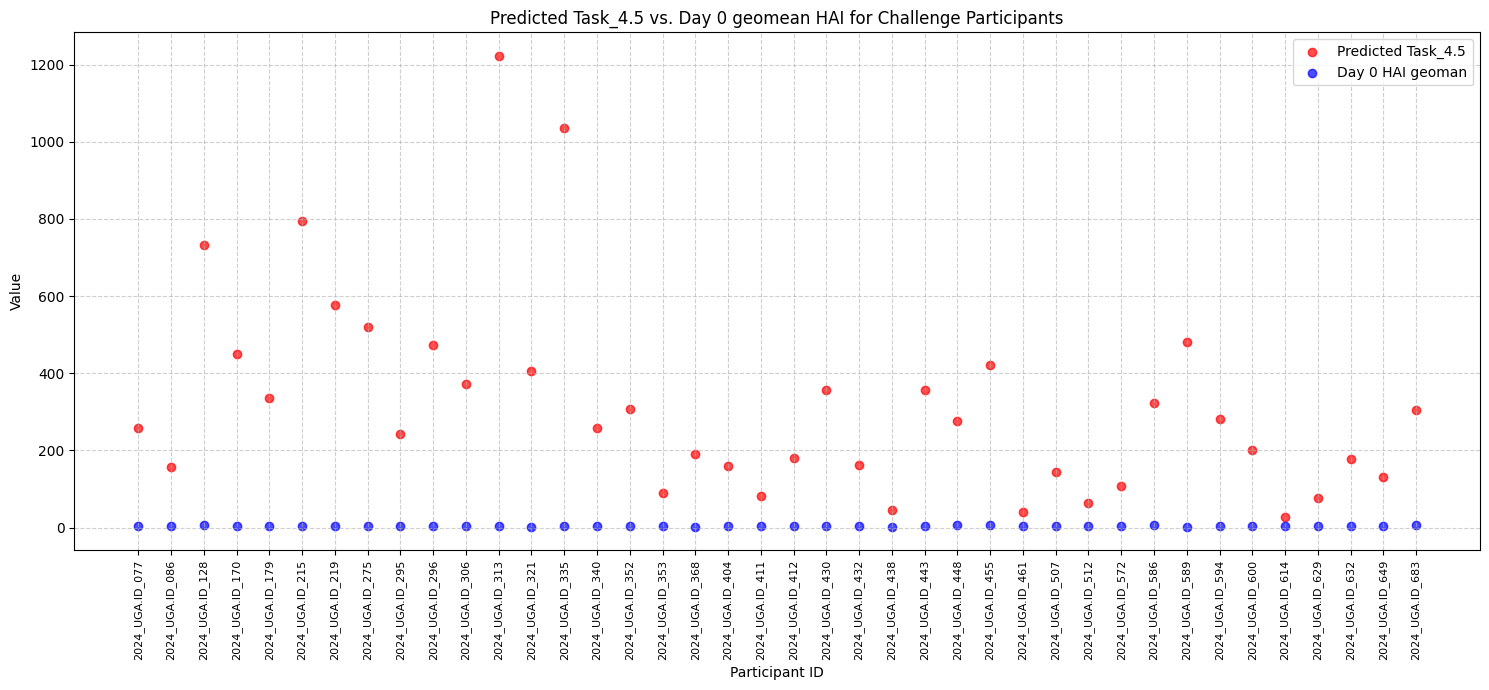

In [116]:
plt.figure(figsize=(15, 7))

# Plot predicted Task_4.5 values
plt.scatter(d0['participant_id'], d0['Task_4.5'], color='red', label='Predicted Task_4.5', alpha=0.7)

# Plot Day 0 HAI values (d0 value)
plt.scatter(d0['participant_id'], d0['geomean_d0'], color='blue', label='Day 0 HAI geoman', alpha=0.7)

plt.xlabel('Participant ID')
plt.ylabel('Value')
plt.title('Predicted Task_4.5 vs. Day 0 geomean HAI for Challenge Participants')
plt.xticks(rotation=90, fontsize=8) # Rotate x-axis labels for readability
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
results.to_csv(SUBMISSION_PATH + '/task_4_5.csv', index=False)

In [ ]:
#make the same plot for a random 40 sample of the df_train_filtered
random_sample = df_train_filtered.sample(n=40, random_state=42)
plt.figure(figsize=(15, 7))

plt